In [1]:
import requests
import pandas as pd

url = "https://api.census.gov/data/timeseries/idb/5year?get=POP,MPOP0_4,FPOP0_4&for=country:643&time=2015"
r = requests.get(url)
data = r.json()
df = pd.DataFrame(data[1:], columns=data[0])

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [2]:
import requests

url = "https://api.census.gov/data/timeseries/idb/5year?get=POP,MPOP0_4,FPOP0_4&for=country:643&time=2015"
r = requests.get(url)

print(r.status_code)      # должен быть 200
print(r.headers['Content-Type'])  # должен содержать 'application/json'

try:
    data = r.json()
except Exception as e:
    print("Ошибка JSON:", e)
    print("Ответ сервера:")
    print(r.text[:500])  # первые 500 символов ответа


400
text/plain;charset=utf-8
Ошибка JSON: Expecting value: line 1 column 1 (char 0)
Ответ сервера:
error: unknown/unsupported geography hierarchy


In [8]:
import pandas as pd

df = pd.read_csv("data/data 2.1/cohort_5_years.csv")
print(df.columns.tolist())
print(df.head())

['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'FREQ', 'Frequency of observation', 'TERRITORIAL_LEVEL', 'Territorial level', 'TERRITORIAL_TYPE', 'Territorial typology', 'REF_AREA', 'Reference area', 'MEASURE', 'Measure', 'AGE', 'Age', 'SEX', 'Sex', 'UNIT_MEASURE', 'Unit of measure', 'TIME_PERIOD', 'Time period', 'OBS_VALUE', 'Observation value', 'COUNTRY', 'Country', 'OBS_STATUS', 'Observation status', 'UNIT_MULT', 'Unit multiplier', 'DECIMALS', 'Decimals']
  STRUCTURE                              STRUCTURE_ID  \
0  DATAFLOW  OECD.CFE.EDS:DSD_REG_DEMO@DF_POP_5Y(1.0)   
1  DATAFLOW  OECD.CFE.EDS:DSD_REG_DEMO@DF_POP_5Y(1.0)   
2  DATAFLOW  OECD.CFE.EDS:DSD_REG_DEMO@DF_POP_5Y(1.0)   
3  DATAFLOW  OECD.CFE.EDS:DSD_REG_DEMO@DF_POP_5Y(1.0)   
4  DATAFLOW  OECD.CFE.EDS:DSD_REG_DEMO@DF_POP_5Y(1.0)   

                              STRUCTURE_NAME ACTION FREQ  \
0  Population by 5-year age groups - Regions      I    A   
1  Population by 5-year age groups - Regions      I    A   
2  P

In [10]:
print(df['TIME_PERIOD'].min(), df['TIME_PERIOD'].max())
russia_data = df[df['COUNTRY'] == 'RUS']
print(russia_data['TIME_PERIOD'].min(), russia_data['TIME_PERIOD'].max())

2018 2022
nan nan


Данные по
https://ec.europa.eu/eurostat/databrowser/view/demo_pjan/default/table?lang=en
не подходят.

1960: 223 rows with NaN
1970: 217 rows with NaN
1980: 164 rows with NaN
1990: 78 rows with NaN
2002: 6 rows with NaN
2007: 4 rows with NaN
2012: 1 rows with NaN


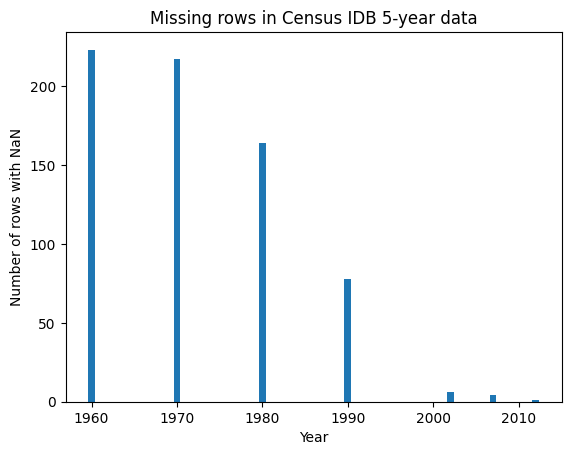

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from time import sleep

BASE = "https://api.census.gov/data/timeseries/idb/5year"
YEARS = [1960, 1970, 1980, 1990, 2002, 2007, 2012]

def fetch_all_countries_age_sex(year):
    params = {
        "get": "NAME,GENC,group(IDB5YEAR)",
        "time": year,
        "for": "genc standard countries and areas:*"
    }
    resp = requests.get(BASE, params=params)
    resp.raise_for_status()
    data = resp.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    return df

nan_counts = {}
for y in YEARS:
    try:
        df = fetch_all_countries_age_sex(y)
        nan_counts[y] = df.isna().any(axis=1).sum()
        sleep(1)  # небольшая пауза между запросами
    except Exception as e:
        print(f"Error for {y}: {e}")
        nan_counts[y] = None

# Вывод числа строк с NaN
for y, n in nan_counts.items():
    print(f"{y}: {n} rows with NaN")

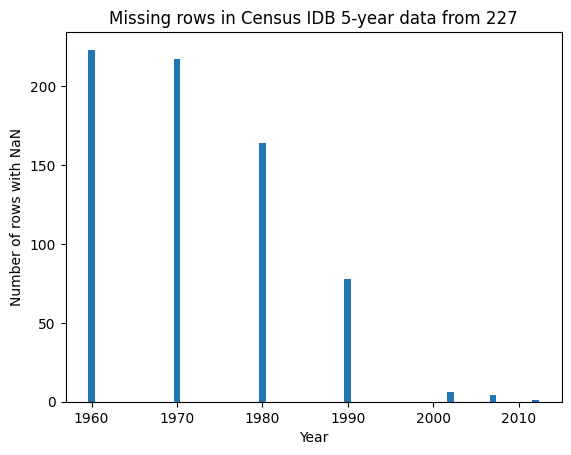

In [ ]:

# Диаграмма
plt.bar(nan_counts.keys(), nan_counts.values())
plt.xlabel("Year")
plt.ylabel("Number of rows with NaN")
df_len = df.shape
plt.title(f"Missing rows in Census IDB 5-year data from {df.shape[0]}")
plt.show()


In [29]:
print(df.columns)
print(df.head(2))

Index(['NAME', 'GENC', 'AREA_KM2', 'ASFR15_19', 'ASFR20_24', 'ASFR25_29',
       'ASFR30_34', 'ASFR35_39', 'ASFR40_44', 'ASFR45_49',
       ...
       'POP90_94', 'POP95_99', 'POP_DENS', 'RNI', 'SEXRATIO', 'SRB', 'TFR',
       'YR', 'time', 'genc standard countries and areas'],
      dtype='object', length=120)
                   NAME GENC AREA_KM2 ASFR15_19 ASFR20_24 ASFR25_29 ASFR30_34  \
0               Andorra   AD      468      12.3      41.1      73.7      89.9   
1  United Arab Emirates   AE    83600      20.1      69.6      76.0      68.5   

  ASFR35_39 ASFR40_44 ASFR45_49  ... POP90_94 POP95_99 POP_DENS    RNI  \
0      40.4      13.3       0.7  ...      417       83    182.0  0.294   
1      53.7      28.9      11.4  ...      768      189    102.9  0.920   

  SEXRATIO    SRB     TFR    YR  time genc standard countries and areas  
0    1.067  1.070  1.3572  2012  2012                                AD  
1    2.802  1.030  1.6406  2012  2012                                AE 

In [30]:
import requests
import pandas as pd
from time import sleep

BASE = "https://api.census.gov/data/timeseries/idb/5year"

def fetch_all_countries_age_sex(year):
    params = {
        "get": "NAME,GENC,AREA_KM2,POP0_4,POP5_9,POP10_14,POP15_19,POP20_24,POP25_29,"
               "POP30_34,POP35_39,POP40_44,POP45_49,POP50_54,POP55_59,POP60_64,"
               "POP65_69,POP70_74,POP75_79,POP80_84,POP85_89,POP90_94,POP95_99",
        "time": year,
        "for": "genc standard countries and areas:*"
    }
    resp = requests.get(BASE, params=params)
    resp.raise_for_status()
    data = resp.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    # Убираем лишние столбцы
    df = df.drop(columns=["genc standard countries and areas"])
    return df

all_years = []
for year in range(2000, 2022):
    try:
        df_year = fetch_all_countries_age_sex(year)
        df_year["TIME_PERIOD"] = year
        all_years.append(df_year)
        sleep(0.2)  
    except Exception as e:
        print(f"Error fetching year {year}: {e}")

df_all = pd.concat(all_years, ignore_index=True)

# Сохраняем в CSV
df_all.to_csv("data/data2/cohort_age_sex_2000_2022.csv", index=False)
print(df_all.head())
print(f"Total rows: {len(df_all)}")


                   NAME GENC AREA_KM2   POP0_4   POP5_9 POP10_14 POP15_19  \
0               Andorra   AD      468     3726     3582     3083     3975   
1  United Arab Emirates   AE    83600   266036   233454   205413   210998   
2           Afghanistan   AF   652230  4760823  3712731  2963515  2218562   
3   Antigua and Barbuda   AG      443     8079     7299     6749     6419   
4              Anguilla   AI       91     1056     1015     1108      913   

  POP20_24 POP25_29 POP30_34  ... POP60_64 POP65_69 POP70_74 POP75_79  \
0     5020     5547     5762  ...     2433     2288     2069     1744   
1   297197   483583   477017  ...    24908    11592     8269     6061   
2  1913106  1670884  1391275  ...   371452   263404   168133    92264   
3     6126     6059     6596  ...     1814     1576     1379     1134   
4      828      934     1003  ...      308      252      224      180   

  POP80_84 POP85_89 POP90_94 POP95_99  time TIME_PERIOD  
0      878      470      127       14  2

In [32]:
import requests
import pandas as pd
from time import sleep

BASE = "https://api.census.gov/data/timeseries/idb/5year"

def fetch_all_countries_age_sex(year):
    params = {
        "get": "NAME,GENC,AREA_KM2,POP0_4,POP5_9,POP10_14,POP15_19,POP20_24,POP25_29,"
               "POP30_34,POP35_39,POP40_44,POP45_49,POP50_54,POP55_59,POP60_64,"
               "POP65_69,POP70_74,POP75_79,POP80_84,POP85_89,POP90_94,POP95_99",
        "time": year,
        "for": "genc standard countries and areas:*"
    }
    resp = requests.get(BASE, params=params)
    resp.raise_for_status()
    data = resp.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    df = df.drop(columns=["genc standard countries and areas"])
    df["TIME_PERIOD"] = year
    return df

all_years = []

# Годы 1970–1999
for year in range(1970, 2000):
    try:
        df_year = fetch_all_countries_age_sex(year)
        all_years.append(df_year)
        sleep(0.2)
    except Exception as e:
        print(f"Error fetching year {year}: {e}")

df_2000_2022 = pd.read_csv("data/data2/cohort_age_sex_2000_2022.csv")

df_all = pd.concat(all_years + [df_2000_2022], ignore_index=True)

df_all.to_csv("data/data2/cohort_age_sex_1970_2022.csv", index=False)
print(df_all.head())
print(f"Total rows: {len(df_all)}")


                   NAME GENC AREA_KM2 POP0_4 POP5_9 POP10_14 POP15_19  \
0               Andorra   AD      468   None   None     None     None   
1  United Arab Emirates   AE    83600   None   None     None     None   
2           Afghanistan   AF   652230   None   None     None     None   
3   Antigua and Barbuda   AG      443   None   None     None     None   
4              Anguilla   AI       91   None   None     None     None   

  POP20_24 POP25_29 POP30_34  ... POP60_64 POP65_69 POP70_74 POP75_79  \
0     None     None     None  ...     None     None     None     None   
1     None     None     None  ...     None     None     None     None   
2     None     None     None  ...     None     None     None     None   
3     None     None     None  ...     None     None     None     None   
4     None     None     None  ...     None     None     None     None   

  POP80_84 POP85_89 POP90_94 POP95_99  time TIME_PERIOD  
0     None     None     None     None  1970        1970  
1     

In [ ]:
import pandas as pd

# Загружаем объединённый файл
df = pd.read_csv("data/data2/cohort_age_sex_1970_2022.csv")
df_previous = pd.read_csv("output/merged_worldbank_long_no_nan.csv")


# Удаляем столбец TIME_PERIOD
#df = df.drop(columns=["TIME_PERIOD"])

# Сохраняем обратно (если нужно)
df.to_csv("data/data2/cohort_age_sex_1970_2022.csv", index=False)

# Выводим список уникальных стран
countries = df["NAME"].unique()
print(countries)
print(df_previous['country_code'].unique())


['Andorra' 'United Arab Emirates' 'Afghanistan' 'Antigua and Barbuda'
 'Anguilla' 'Albania' 'Armenia' 'Angola' 'Argentina' 'American Samoa'
 'Austria' 'Australia' 'Aruba' 'Azerbaijan' 'Bosnia and Herzegovina'
 'Barbados' 'Bangladesh' 'Belgium' 'Burkina Faso' 'Bulgaria' 'Bahrain'
 'Burundi' 'Benin' 'Saint Barthelemy' 'Bermuda' 'Brunei' 'Bolivia'
 'Brazil' 'Bahamas, The' 'Bhutan' 'Botswana' 'Belarus' 'Belize' 'Canada'
 'Congo (Kinshasa)' 'Central African Republic' 'Congo (Brazzaville)'
 'Switzerland' 'Côte d’Ivoire' 'Cook Islands' 'Chile' 'Cameroon' 'China'
 'Colombia' 'Costa Rica' 'Cuba' 'Cabo Verde' 'Curaçao' 'Cyprus' 'Czechia'
 'Germany' 'Djibouti' 'Denmark' 'Dominica' 'Dominican Republic' 'Algeria'
 'Ecuador' 'Estonia' 'Egypt' 'Eritrea' 'Spain' 'Ethiopia' 'Finland' 'Fiji'
 'Micronesia, Federated States of' 'Faroe Islands' 'France' 'Gabon'
 'United Kingdom' 'Grenada' 'Georgia' 'Guernsey' 'Ghana' 'Gibraltar'
 'Greenland' 'Gambia, The' 'Guinea' 'Equatorial Guinea' 'Greece'
 'Guatemala' 

In [43]:
name_to_code = {
    "Andorra": "AND",
    "United Arab Emirates": "AE",
    "Afghanistan": "AFG",
    "Antigua and Barbuda": "ATG",
    "Anguilla": "AIA",
    "Albania": "ALB",
    "Armenia": "ARM",
    "Angola": "AGO",
    "Argentina": "ARG",
    "American Samoa": "ASM",
    "Austria": "AUT",
    "Australia": "AUS",
    "Aruba": "ABW",
    "Azerbaijan": "AZE",
    "Bosnia and Herzegovina": "BIH",
    "Barbados": "BRB",
    "Bangladesh": "BGD",
    "Belgium": "BEL",
    "Burkina Faso": "BFA",
    "Bulgaria": "BGR",
    "Bahrain": "BHR",
    "Burundi": "BDI",
    "Benin": "BEN",
    "Saint Barthelemy": "BLM",
    "Bermuda": "BMU",
    "Brunei": "BRN",
    "Bolivia": "BOL",
    "Brazil": "BRA",
    "Bahamas, The": "BHS",
    "Bhutan": "BTN",
    "Botswana": "BWA",
    "Belarus": "BLR",
    "Belize": "BLZ",
    "Canada": "CAN",
    "Congo (Kinshasa)": "COD",
    "Central African Republic": "CAF",
    "Congo (Brazzaville)": "COG",
    "Switzerland": "CHE",
    "Côte d’Ivoire": "CIV",
    "Cook Islands": "COK",
    "Chile": "CHL",
    "Cameroon": "CMR",
    "China": "CHN",
    "Colombia": "COL",
    "Costa Rica": "CRI",
    "Cuba": "CUB",
    "Cabo Verde": "CPV",
    "Curaçao": "CUW",
    "Cyprus": "CYP",
    "Czechia": "CZE",
    "Germany": "DEU",
    "Djibouti": "DJI",
    "Denmark": "DNK",
    "Dominica": "DMA",
    "Dominican Republic": "DOM",
    "Algeria": "DZA",
    "Ecuador": "ECU",
    "Estonia": "EST",
    "Egypt": "EGY",
    "Spain": "ESP",
    "Ethiopia": "ETH",
    "Finland": "FIN",
    "Fiji": "FJI",
    "Micronesia, Federated States of": "FSM",
    "Faroe Islands": "FRO",
    "France": "FRA",
    "Gabon": "GAB",
    "United Kingdom": "GBR",
    "Grenada": "GRD",
    "Georgia": "GEO",
    "Guernsey": "GGY",
    "Ghana": "GHA",
    "Gibraltar": "GIB",
    "Greenland": "GRL",
    "Gambia, The": "GMB",
    "Guinea": "GIN",
    "Equatorial Guinea": "GNQ",
    "Greece": "GRC",
    "Guatemala": "GTM",
    "Guam": "GUM",
    "Guinea-Bissau": "GNB",
    "Guyana": "GUY",
    "Hong Kong": "HKG",
    "Honduras": "HND",
    "Croatia": "HRV",
    "Haiti": "HTI",
    "Hungary": "HUN",
    "Indonesia": "IDN",
    "Ireland": "IRL",
    "Israel": "ISR",
    "Isle of Man": "IMN",
    "India": "IND",
    "Iraq": "IRQ",
    "Iran": "IRN",
    "Iceland": "ISL",
    "Italy": "ITA",
    "Jersey": "JEY",
    "Jamaica": "JAM",
    "Jordan": "JOR",
    "Japan": "JPN",
    "Kenya": "KEN",
    "Kyrgyzstan": "KGZ",
    "Cambodia": "KHM",
    "Kiribati": "KIR",
    "Comoros": "COM",
    "Saint Kitts and Nevis": "KNA",
    "Korea, North": "PRK",
    "Korea, South": "KOR",
    "Kuwait": "KWT",
    "Cayman Islands": "CYM",
    "Kazakhstan": "KAZ",
    "Laos": "LAO",
    "Lebanon": "LBN",
    "Saint Lucia": "LCA",
    "Liechtenstein": "LIE",
    "Sri Lanka": "LKA",
    "Liberia": "LBR",
    "Lesotho": "LSO",
    "Lithuania": "LTU",
    "Luxembourg": "LUX",
    "Latvia": "LVA",
    "Libya": "LBY",
    "Morocco": "MAR",
    "Monaco": "MCO",
    "Moldova": "MDA",
    "Montenegro": "MNE",
    "Saint Martin": "MAF",
    "Madagascar": "MDG",
    "Marshall Islands": "MHL",
    "North Macedonia": "MKD",
    "Mali": "MLI",
    "Burma": "MMR",
    "Mongolia": "MNG",
    "Macau": "MAC",
    "Northern Mariana Islands": "MNP",
    "Mauritania": "MRT",
    "Montserrat": "MSR",
    "Malta": "MLT",
    "Mauritius": "MUS",
    "Maldives": "MDV",
    "Malawi": "MWI",
    "Mexico": "MEX",
    "Malaysia": "MYS",
    "Mozambique": "MOZ",
    "Namibia": "NAM",
    "New Caledonia": "NCL",
    "Niger": "NER",
    "Nigeria": "NGA",
    "Nicaragua": "NIC",
    "Netherlands": "NLD",
    "Norway": "NOR",
    "Nepal": "NPL",
    "Nauru": "NRU",
    "New Zealand": "NZL",
    "Oman": "OMN",
    "Panama": "PAN",
    "Peru": "PER",
    "French Polynesia": "PYF",
    "Papua New Guinea": "PNG",
    "Philippines": "PHL",
    "Pakistan": "PAK",
    "Poland": "POL",
    "Saint Pierre and Miquelon": "SPM",
    "Puerto Rico": "PRI",
    "Portugal": "PRT",
    "Palau": "PLW",
    "Paraguay": "PRY",
    "Qatar": "QAT",
    "Romania": "ROU",
    "Serbia": "SRB",
    "Russia": "RUS",
    "Rwanda": "RWA",
    "Saudi Arabia": "SAU",
    "Solomon Islands": "SLB",
    "Seychelles": "SYC",
    "Sudan": "SDN",
    "Sweden": "SWE",
    "Singapore": "SGP",
    "Saint Helena, Ascension, and Tristan da Cunha": "SHN",
    "Slovenia": "SVN",
    "Slovakia": "SVK",
    "Sierra Leone": "SLE",
    "San Marino": "SMR",
    "Senegal": "SEN",
    "Somalia": "SOM",
    "Suriname": "SUR",
    "South Sudan": "SSD",
    "Sao Tome and Principe": "STP",
    "El Salvador": "SLV",
    "Sint Maarten": "SXM",
    "Syria": "SYR",
    "Eswatini": "SWZ",
    "Turks and Caicos Islands": "TCA",
    "Chad": "TCD",
    "Togo": "TGO",
    "Thailand": "THA",
    "Tajikistan": "TJK",
    "Timor-Leste": "TLS",
    "Turkmenistan": "TKM",
    "Tunisia": "TUN",
    "Tonga": "TON",
    "Turkey": "TUR",
    "Trinidad and Tobago": "TTO",
    "Tuvalu": "TUV",
    "Taiwan": "TWN",
    "Tanzania": "TZA",
    "Ukraine": "UKR",
    "Uganda": "UGA",
    "United States": "USA",
    "Uruguay": "URY",
    "Uzbekistan": "UZB",
    "Saint Vincent and the Grenadines": "VCT",
    "Venezuela": "VEN",
    "Virgin Islands, British": "VGB",
    "Virgin Islands, U.S.": "VIR",
    "Vietnam": "VNM",
    "Vanuatu": "VUT",
    "Wallis and Futuna": "WLF",
    "Samoa": "WSM",
    "Gaza Strip": "PSG",
    "Kosovo": "XKX",
    "West Bank": "PSE",
    "Yemen": "YEM",
    "South Africa": "ZAF",
    "Zambia": "ZMB",
    "Zimbabwe": "ZWE"
}

In [44]:
df = pd.read_csv("data/data2/cohort_age_sex_1970_2022.csv")
df_previous = pd.read_csv("output/merged_worldbank_long_no_nan.csv")
print(df.columns)
print(df_previous.columns)

Index(['NAME', 'GENC', 'AREA_KM2', 'POP0_4', 'POP5_9', 'POP10_14', 'POP15_19',
       'POP20_24', 'POP25_29', 'POP30_34', 'POP35_39', 'POP40_44', 'POP45_49',
       'POP50_54', 'POP55_59', 'POP60_64', 'POP65_69', 'POP70_74', 'POP75_79',
       'POP80_84', 'POP85_89', 'POP90_94', 'POP95_99', 'time'],
      dtype='object')
Index(['country_code', 'year', 'age_0_14_share', 'age_65_plus_share',
       'crude_birth_rate', 'crude_death_rate', 'fertility_rate',
       'life_expectancy', 'net_migration', 'population', 'urban_share',
       'gdppc'],
      dtype='object')


In [ ]:
set_cohort = set(df['NAME'].map(name_to_code).dropna())
set_previous = set(df_previous['country_code'].dropna())

# страны, которых нет в cohort: должно быть 0 т.к. фильтровали NaN в изначальных данных 
missing_in_cohort = set_previous - set_cohort
print("Страны в предыдущей таблице, которых нет в cohort:", missing_in_cohort)

Страны в cohort, которых нет в предыдущей таблице: {'AE', 'AND', 'SXM', 'UZB', 'FSM', 'AIA', 'SPM', 'MDA', 'VCT', 'TUV', 'UKR', 'TCA', 'WLF', 'KIR', 'GIB', 'XKX', 'VUT', 'MSR', 'TWN', 'SHN', 'ISR', 'PSE', 'WSM', 'LIE', 'SSD', 'GUM', 'KAZ', 'EST', 'CUW', 'MHL', 'TLS', 'MDV', 'BRN', 'BLZ', 'GEO', 'PLW', 'SVK', 'VIR', 'GRD', 'MAF', 'NCL', 'ATG', 'BTN', 'FJI', 'TJK', 'BLR', 'TON', 'NRU', 'SUR', 'LTU', 'GUY', 'PYF', 'PNG', 'TKM', 'BMU', 'IMN', 'KGZ', 'SLB', 'AZE', 'PSG', 'GRL', 'LUX', 'KNA', 'ARM', 'CYM', 'CZE', 'FRO', 'COK', 'MNP', 'PRK', 'LVA', 'JEY', 'VGB', 'GGY', 'ABW', 'SOM', 'BHS', 'MAC', 'ASM', 'SMR', 'BLM', 'MCO'}
Страны в предыдущей таблице, которых нет в cohort: set()
Полное совпадение: False


In [50]:
import pandas as pd

# создаём копию df для join
df_cohort = df.copy()
df_cohort['country_code'] = df_cohort['NAME'].map(name_to_code)
df_cohort = df_cohort.drop(columns=['NAME', 'GENC'])
print(df_previous.columns)
print(df_cohort.columns)


Index(['country_code', 'year', 'age_0_14_share', 'age_65_plus_share',
       'crude_birth_rate', 'crude_death_rate', 'fertility_rate',
       'life_expectancy', 'net_migration', 'population', 'urban_share',
       'gdppc'],
      dtype='object')
Index(['AREA_KM2', 'POP0_4', 'POP5_9', 'POP10_14', 'POP15_19', 'POP20_24',
       'POP25_29', 'POP30_34', 'POP35_39', 'POP40_44', 'POP45_49', 'POP50_54',
       'POP55_59', 'POP60_64', 'POP65_69', 'POP70_74', 'POP75_79', 'POP80_84',
       'POP85_89', 'POP90_94', 'POP95_99', 'year', 'country_code'],
      dtype='object')


In [54]:
df['country_code'] = df['NAME'].map(name_to_code)
df['country_code'] = df['country_code'].astype(str).str.upper()
df_previous['country_code'] = df_previous['country_code'].astype(str).str.upper()
age_cols = [c for c in df.columns if c.startswith('POP')]
df_cohort_sub = df[['country_code', 'time', 'AREA_KM2'] + age_cols] if 'time' in df.columns else df[['country_code', 'year'] + age_cols]
if 'time' in df_cohort_sub.columns:
    df_cohort_sub = df_cohort_sub.rename(columns={'time':'year'})
df_cohort_sub = df_cohort_sub.drop_duplicates(subset=['country_code', 'year'], keep='last')
merged = pd.merge(df_previous, df_cohort_sub, how='left', on=['country_code', 'year'])
merged.to_csv("output/basic_with_cohort.csv", index=False)
print("merged.shape:", merged.shape)
print("age cols added:", age_cols)
print("rows with any age NaN (count):", merged[age_cols].isna().any(axis=1).sum())

merged.shape: (9072, 32)
age cols added: ['POP0_4', 'POP5_9', 'POP10_14', 'POP15_19', 'POP20_24', 'POP25_29', 'POP30_34', 'POP35_39', 'POP40_44', 'POP45_49', 'POP50_54', 'POP55_59', 'POP60_64', 'POP65_69', 'POP70_74', 'POP75_79', 'POP80_84', 'POP85_89', 'POP90_94', 'POP95_99']
rows with any age NaN (count): 3705


In [19]:
import pandas as pd
import glob
import os

mortality_path = "data/un/mortality1"
lookup_path = "data/un/ddf--entities--location--country_area.csv"

lookup = pd.read_csv(lookup_path)
valid_country_areas = lookup.loc[lookup['is--country_area'] == True, 'country_area'].unique()

csv_files = glob.glob(os.path.join(mortality_path, "*.csv"))

dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    if 'country_area' in df.columns:
        df = df[df['country_area'].isin(valid_country_areas)]
        dfs.append(df)
    else:
        print("Skipping file (no country_area column):", file)

combined = pd.concat(dfs, ignore_index=True)

combined.to_csv("data/un/mortality_combined.csv", index=False)
print("Done! Combined mortality data saved.")


Skipping file (no country_area column): data/un/mortality1/ddf--datapoints--deaths--by--ad_hoc_groups--time--age_group_1year.csv
Skipping file (no country_area column): data/un/mortality1/ddf--datapoints--deaths--by--development_group--time--age_group_1year.csv
Skipping file (no country_area column): data/un/mortality1/ddf--datapoints--deaths--by--geographic_region--time--age_group_1year.csv
Skipping file (no country_area column): data/un/mortality1/ddf--datapoints--deaths--by--income_group--time--age_group_1year.csv
Skipping file (no country_area column): data/un/mortality1/ddf--datapoints--deaths--by--sdg_region--time--age_group_1year.csv
Skipping file (no country_area column): data/un/mortality1/ddf--datapoints--deaths--by--subregion--time--age_group_1year.csv
Skipping file (no country_area column): data/un/mortality1/ddf--datapoints--deaths--by--world--time--age_group_1year.csv
Done! Combined mortality data saved.


In [ ]:
import pandas as pd

combined = pd.read_csv("data/un/mortality_combined.csv")

# Заменяем специальные значения на число
combined['age_group_1year'] = combined['age_group_1year'].replace('100plus', 100).astype(int)

# Создаём 5-летние когорты в виде числа
combined['age_group_5year'] = (combined['age_group_1year'] // 5) * 5

# Преобразуем 5-летние когорты в строковый формат '0_4', '5_9', ...
def format_age_group(age5):
    upper = age5 + 4 if age5 < 100 else 100
    return f"{age5}_{upper}"

combined['age_group_5year'] = combined['age_group_5year'].apply(format_age_group)

# Группируем и суммируем deaths
aggregated = combined.groupby(['country_area', 'time', 'age_group_5year'], as_index=False)['deaths'].sum()

# Сохраняем результат
aggregated.to_csv("data/un/mortality_combined.csv", index=False)
print("Done! Mortality data aggregated by 5-year cohorts saved.")


/tmp/ipykernel_3858/707732860.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv("data/un/mortality_combined.csv")


Done! Mortality data aggregated by 5-year cohorts saved.


In [23]:
import pandas as pd
import glob
import os

lookup = pd.read_csv("data/un/ddf--entities--location--country_area.csv")
valid_country_areas = lookup.loc[lookup['is--country_area'] == True, 'country_area'].unique()
combined_mortality = aggregated
fertility_path = "data/un/asfertility5"
fertility_files = glob.glob(os.path.join(fertility_path, "*.csv"))
dfs = []
for file in fertility_files:
    df = pd.read_csv(file)
    if 'country_area' in df.columns:
        df = df[df['country_area'].isin(valid_country_areas)]
        dfs.append(df)
combined_fertility = pd.concat(dfs, ignore_index=True)
combined_fertility.to_csv("data/un/fertility_combined.csv", index=False)

In [ ]:
print(combined_fertility.age_group_5year.values)
print(combined_mortality.age_group_5year.values)
#Добились одинаковых типов

['10_14' '10_14' '10_14' ... '50_54' '50_54' '50_54']
['0_4' '100_100' '10_14' ... '85_89' '90_94' '95_99']


In [27]:
import pandas as pd

mortality = combined_mortality
fertility = pd.read_csv("data/un/fertility_combined.csv")
lookup = pd.read_csv("data/un/ddf--entities--location--country_area.csv")
our_countries = lookup.loc[lookup['is--country_area'] == True, 'country_area'].unique()

mortality = mortality[mortality['country_area'].isin(our_countries)]
fertility = fertility[fertility['country_area'].isin(our_countries)]

years = range(1960, 2022)

missing_countries_mortality = []
for c in our_countries:
    if not all(y in mortality[mortality['country_area']==c]['time'].values for y in years):
        missing_countries_mortality.append(c)

missing_countries_fertility = []
for c in our_countries:
    if not all(y in fertility[fertility['country_area']==c]['time'].values for y in years):
        missing_countries_fertility.append(c)

print("Countries missing mortality data 1960-2022:", missing_countries_mortality)
print("Countries missing fertility data 1960-2022:", missing_countries_fertility)

Countries missing mortality data 1960-2022: []
Countries missing fertility data 1960-2022: []


In [34]:
print(mortality.columns)
print(fertility.columns)
mortality_wide = mortality.pivot_table(
    index=['country_area', 'time'],
    columns='age_group_5year',
    values='deaths',
    fill_value=0
).reset_index()
mortality_wide = mortality_wide.rename(
    columns={col: f"mort_{col}" for col in mortality_wide.columns if col not in ['country_area','time']}
)
print(mortality_wide.columns)
fertility_wide = fertility.pivot_table(
    index=['country_area', 'time'],
    columns='age_group_5year',
    values='asfr', 
    fill_value=0
).reset_index()
fertility_wide = fertility_wide.rename(
    columns={col: f"asfr_{col}" for col in fertility_wide.columns if col not in ['country_area','time']}
)
print(fertility_wide.columns)

Index(['country_area', 'time', 'age_group_5year', 'deaths'], dtype='object')
Index(['country_area', 'time', 'age_group_5year', 'asfr'], dtype='object')
Index(['country_area', 'time', 'mort_0_4', 'mort_100_100', 'mort_10_14',
       'mort_15_19', 'mort_20_24', 'mort_25_29', 'mort_30_34', 'mort_35_39',
       'mort_40_44', 'mort_45_49', 'mort_50_54', 'mort_55_59', 'mort_5_9',
       'mort_60_64', 'mort_65_69', 'mort_70_74', 'mort_75_79', 'mort_80_84',
       'mort_85_89', 'mort_90_94', 'mort_95_99'],
      dtype='object', name='age_group_5year')
Index(['country_area', 'time', 'asfr_10_14', 'asfr_15_19', 'asfr_20_24',
       'asfr_25_29', 'asfr_30_34', 'asfr_35_39', 'asfr_40_44', 'asfr_45_49',
       'asfr_50_54'],
      dtype='object', name='age_group_5year')


In [36]:
combined_wide = pd.merge(mortality_wide, fertility_wide, on=['country_area','time'], how='outer')
combined_wide.to_csv("data/un/un_combined_1960_2022.csv", index=False)
print("Done! Wide-format combined mortality + fertility data saved.")
print(combined_wide.head(2))

Done! Wide-format combined mortality + fertility data saved.
age_group_5year  country_area  time  mort_0_4  mort_100_100  mort_10_14  \
0                           4  1950   160.791           0.0       6.694   
1                           4  1951   158.566           0.0       6.686   

age_group_5year  mort_15_19  mort_20_24  mort_25_29  mort_30_34  mort_35_39  \
0                     7.925       9.402       9.038       8.876       8.667   
1                     7.923       9.396       9.050       8.867       8.649   

age_group_5year  ...  mort_95_99  asfr_10_14  asfr_15_19  asfr_20_24  \
0                ...       0.004       8.386     145.252     335.219   
1                ...       0.003       8.413     145.092     334.756   

age_group_5year  asfr_25_29  asfr_30_34  asfr_35_39  asfr_40_44  asfr_45_49  \
0                   330.193     273.037     213.619     111.618      31.146   
1                   330.873     274.039     214.557     112.040      31.043   

age_group_5year  asf

In [12]:
lookup = pd.read_csv("data/un/ddf--entities--location--country_area.csv")
print(lookup.columns)
lookup = pd.read_csv("output/basic_with_cohort.csv")
print(lookup.columns)
print(lookup.head(2))

Index(['country_area', 'name', 'iso3_code', 'iso2_code', 'sdmx_code',
       'parent_id', 'sub_region', 'geographic_region', 'is--country_area'],
      dtype='object')
Index(['country_code', 'year', 'age_0_14_share', 'age_65_plus_share',
       'crude_birth_rate', 'crude_death_rate', 'fertility_rate',
       'life_expectancy', 'net_migration', 'population', 'urban_share',
       'gdppc', 'POP0_4', 'POP5_9', 'POP10_14', 'POP15_19', 'POP20_24',
       'POP25_29', 'POP30_34', 'POP35_39', 'POP40_44', 'POP45_49', 'POP50_54',
       'POP55_59', 'POP60_64', 'POP65_69', 'POP70_74', 'POP75_79', 'POP80_84',
       'POP85_89', 'POP90_94', 'POP95_99'],
      dtype='object')
  country_code  year  age_0_14_share  age_65_plus_share  crude_birth_rate  \
0          AFG  1960       41.946754           2.823362            50.516   
1          AFG  1961       42.028588           2.809357            50.566   

   crude_death_rate  fertility_rate  life_expectancy  net_migration  \
0            31.672       

In [39]:
import pandas as pd

lookup = pd.read_csv("data/un/ddf--entities--location--country_area.csv")
basic = pd.read_csv("output/basic_with_cohort.csv")

lookup = lookup.loc[lookup['is--country_area'] == True, ['country_area', 'iso3_code']]

combined_wide = pd.read_csv("data/un/un_combined_1960_2022.csv")

combined_wide = combined_wide.merge(lookup, on='country_area', how='left')

# Объединяем с basic по iso3_code и времени
final = combined_wide.merge(
    basic,
    left_on=['iso3_code', 'time'],
    right_on=['country_code', 'year'],
    how='left'
)

final.to_csv("output/final_with_cohort.csv", index=False)
print("Done! Combined with basic_with_cohort saved.")
#где-то здесь я завалил wsl из-за неправильного merge ранее(не сделал wide-табличку). Пришлось по когортам по 5 расфасовывать

Done! Combined with basic_with_cohort saved.


In [40]:
print(final.head(2))

   country_area  time  mort_0_4  mort_100_100  mort_10_14  mort_15_19  \
0             4  1950   160.791           0.0       6.694       7.925   
1             4  1951   158.566           0.0       6.686       7.923   

   mort_20_24  mort_25_29  mort_30_34  mort_35_39  ...  POP50_54  POP55_59  \
0       9.402       9.038       8.876       8.667  ...       NaN       NaN   
1       9.396       9.050       8.867       8.649  ...       NaN       NaN   

   POP60_64  POP65_69  POP70_74  POP75_79  POP80_84  POP85_89  POP90_94  \
0       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
1       NaN       NaN       NaN       NaN       NaN       NaN       NaN   

   POP95_99  
0       NaN  
1       NaN  

[2 rows x 65 columns]
